<a href="https://colab.research.google.com/github/rohini-th/Machine-Learning-project/blob/main/k_means_clustring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Business Usecase: Create customer groups based on their income, age and gender and share them

### K_Means Clustring

### Data Gathering

In [1]:
path = r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/Mall_Customers.csv"
import pandas as pd
df = pd.read_csv(path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Perform basic data quality checks
df.shape


(200, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


### Separate X

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
X = df.drop(columns=['CustomerID','Gender'])
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [8]:
X.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [9]:
X.columns = ['Age','Income','Spending']
X.columns

Index(['Age', 'Income', 'Spending'], dtype='object')

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

con_pipe = make_pipeline(
    SimpleImputer(strategy='median'), # data cleaning
    StandardScaler() # feature scaling
).set_output(transform='pandas')


In [11]:
con_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [12]:
X_pre = con_pipe.fit_transform(X)
X_pre


,Age,Income,Spending
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


### Model Building

In [13]:
from sklearn.cluster import KMeans # donot go for k_means

In [14]:
model = KMeans(n_clusters=3)
model.fit(X_pre)

KMeans(n_clusters=3)

In [15]:
clusters1= model.predict(X_pre)

In [16]:
clusters1

array([1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 1,
       2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1,
       1, 2, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2,
       2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2, 0, 0, 1, 0, 2, 0, 2, 0, 2, 0,
       1, 0, 1, 0, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       0, 0], dtype=int32)

In [17]:
base_cluster_created = X_pre.copy()
base_cluster_created.head(3)

,Age,Income,Spending
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913


In [18]:
base_cluster_created['Clusters'] = clusters1
base_cluster_created.head()

,Age,Income,Spending,Clusters
0,-1.424569,-1.738999,-0.434801,1
1,-1.281035,-1.738999,1.195704,1
2,-1.352802,-1.700830,-1.715913,1
3,-1.137502,-1.700830,1.040418,1
4,-0.563369,-1.662660,-0.395980,1


In [19]:
model.inertia_

295.21224615554877

In [20]:
model2 = KMeans(n_clusters=6)
model2.fit(X_pre)

KMeans(n_clusters=6)

In [21]:
model2.inertia_

134.35277477401493

### Hyperparameter tuning: Choose the optimal value of k using elbow method

In [22]:
pip install yellowbrick

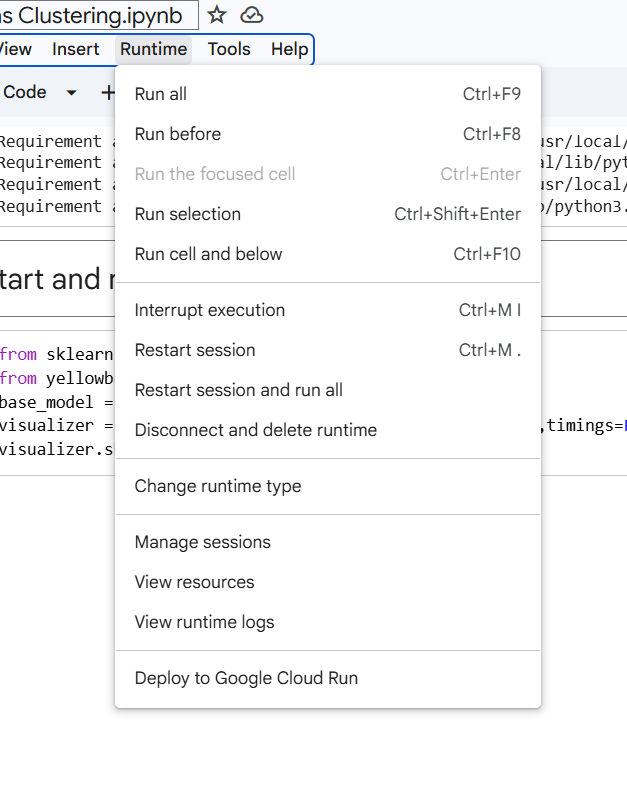

### Keblow visualizer will check the model for k number of clusters ranging between 2-15

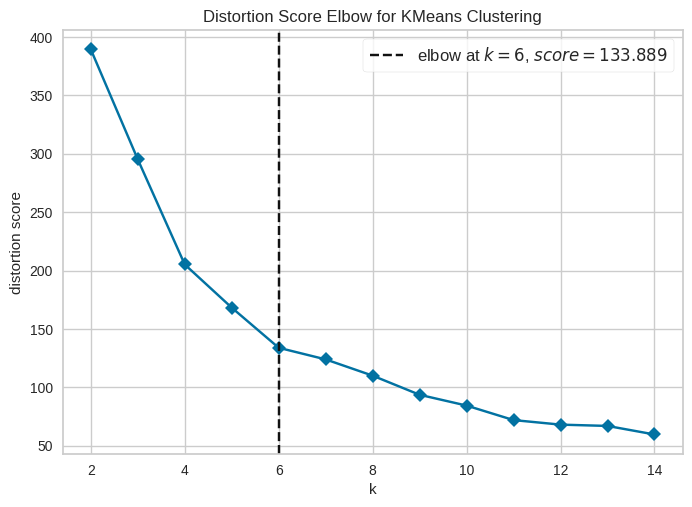

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [23]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import kelbow_visualizer
base_model = KMeans()
visualizer = kelbow_visualizer(base_model,X_pre,k=(2,15),timings=False)
visualizer.show()

### According to the above figure, we shall finalise k=7 as the best cluster formation

In [24]:
final_model = KMeans(n_clusters=7)
final_model.fit(X_pre)


KMeans(n_clusters=7)

In [25]:
final_model.inertia_


124.02235574351596

In [26]:
X_pre.columns

Index(['Age', 'Income', 'Spending'], dtype='object')

In [27]:
final_model.cluster_centers_

array([[ 0.15429838,  1.87564575, -1.09476801],
       [ 1.25472096, -0.24021294, -0.04399777],
       [-0.85043527, -0.14894113, -0.04147777],
       [-0.44191719,  0.99158305,  1.23950275],
       [ 0.47895722, -1.30822992, -1.19644353],
       [ 0.18121089,  0.72929056, -1.38269459],
       [-0.99396865, -1.34734766,  1.06404834]])

In [28]:
cluster_preds = final_model.predict(X_pre)
cluster_preds


array([6, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6,
       4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 1, 6, 4, 2,
       4, 6, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2,
       1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2,
       2, 1, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1,
       1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 3, 2, 3, 5, 3, 5, 3, 5, 3,
       2, 3, 5, 3, 5, 3, 5, 3, 5, 3, 2, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3,
       5, 3, 5, 3, 5, 3, 1, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3,
       5, 3, 5, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3], dtype=int32)

In [29]:
X_pre['Cluster_predictions'] = cluster_preds

In [31]:
X_pre

,Age,Income,Spending,Cluster_predictions
0,-1.424569,-1.738999,-0.434801,6
1,-1.281035,-1.738999,1.195704,6
2,-1.352802,-1.700830,-1.715913,4
3,-1.137502,-1.700830,1.040418,6
4,-0.563369,-1.662660,-0.395980,4
...,...,...,...,...
195,-0.276302,2.268791,1.118061,3
196,0.441365,2.497807,-0.861839,0
197,-0.491602,2.497807,0.923953,3
198,-0.491602,2.917671,-1.250054,0


In [32]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [33]:
df['Customer_Groups'] = cluster_preds

In [34]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Customer_Groups
0,1,Male,19,15,39,6
1,2,Male,21,15,81,6
2,3,Female,20,16,6,4
3,4,Female,23,16,77,6
4,5,Female,31,17,40,4


In [35]:
df.to_csv("Customer_Groups_Predicted_KMeans.csv",index=False)

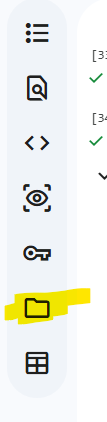

**To view the save file,go to folder icon and download saved file.This file are available until Runtime**